In [22]:
# Downloading the needed libraries
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp
import time
from diffrax import *
import pandas as pd
import scipy.signal as signal
import scipy.special as special
from scipy.optimize import minimize
from scipy.optimize import bisect
from scipy.stats import norm
from scipy.stats import multivariate_normal
from concurrent.futures import ProcessPoolExecutor
num_processes = 8  # Adjust based on your machine's CPU cores and task requirements



# Importing the other codes we need
from controls import *
from hybrid_joint import *
from Jackels import impliedVolJaeckelRational
%matplotlib inline

Same equation as in `dynamics_rough_vol.ipynb`, but with `M` trajectories.

In [23]:
# global parameters

H = 0.1
M = 10000
grid_points = 1000
kappa = 1
T = 1
# 3 factor case:
#rho01, rho02, rho12 = 0.9, 0.9, 0.9
# 2 factor case:
#rho = 0.9
epsilon = 1/grid_points
times = jnp.arange(0, 1, epsilon)
lag = epsilon
solver_epsilon = 0.2*epsilon

In [24]:
# Let's parallelise the creation of the iid noise paths
# See the file hybrid_joint for the options regarding different correlation structures. Different functions are needed for fully correlated noise

from concurrent.futures import ProcessPoolExecutor

num_processes = 8  # Adjust based on your machine's CPU cores and task requirements

args = (grid_points, T, kappa)
# 3 factor case:
#args = (rho01, rho02, rho12, grid_points, T, kappa)
# 2 factor case:
#args = (rho, grid_points, T, kappa)

with ProcessPoolExecutor(max_workers=num_processes) as executor:
    futures = [executor.submit(degenerate_fbm_1_bm_1_bm_wrapper, args) for _ in range(M)]
    results = [future.result() for future in futures]

# 3 x 10k sample paths takes 10 seconds on my laptop, much better

# keep in mind though, unless the rho's are parameters this only needs to be run once for all passes of the calibration (unless there is something to be
# gained from using independent noises across different calibration steps)

# it's worth checking that the different sample paths are indeed independent

list_fbm, list_bm1, list_bm2 = zip(*results)

stacked_fbm = jnp.stack(list_fbm).T
stacked_bm1 = jnp.stack(list_bm1).T
stacked_bm2 = jnp.stack(list_bm2).T

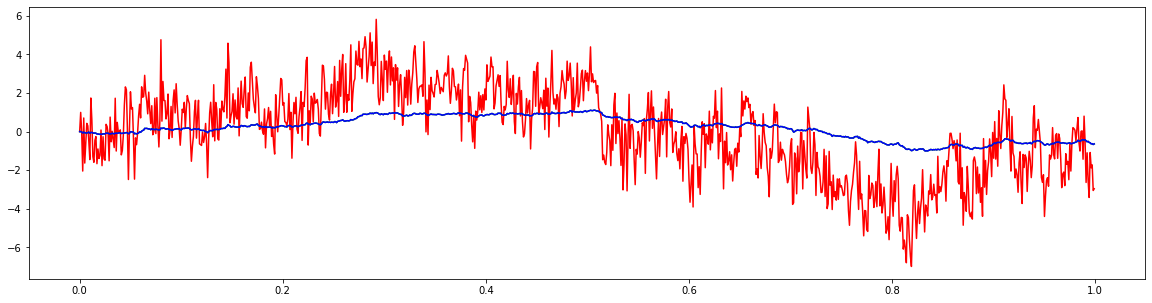

In [25]:
sample = 5

plt.figure(figsize=(20, 5))
plt.plot(times, stacked_fbm[:,sample], color = 'red')
plt.plot(times, stacked_bm1[:,sample], color = 'green')
plt.plot(times, stacked_bm2[:,sample], color = 'blue')

In [26]:
# define the controls

bm1_interp = LinearInterpolation(times, stacked_bm1)
bm2_interp = LinearInterpolation(times, stacked_bm2)
fbm_interp = LinearInterpolation(times, stacked_fbm)

bm1_control = evaluate_and_reshape(bm1_interp.evaluate)
bm2_control = evaluate_and_reshape(bm2_interp.evaluate)
fbm_control = evaluate_and_reshape(fbm_interp.evaluate)
fbm_fun = lambda t: fbm_interp.evaluate(0,t)
fbm_lagged_control_temp = lagged_control(fbm_fun, lag)
fbm_lagged_control = lambda s,t: fbm_lagged_control_temp(s,t).reshape(1, M)
bm_control = stack_controls(bm1_control, bm2_control)
lead_lag_control = stack_controls(fbm_lagged_control, bm_control)

#check shape
lead_lag_control(0,0.5)[:,5].shape

# this is a function that returns a jnp array with the following structure: lead_lag_control(s,t)[lagged_fbm, bm1, bm2; sample_paths]

(3,)

Quadratic rough Heston model - RDE version

$$ \begin{cases}\mathrm{d}S_t = S_t\sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d}W_t - \frac 12 S_t(a(Z_t - b)^2 + c) \mathrm{d}t \\ \mathrm{d}Z_t = \lambda \theta(t)\mathrm{d}t + \lambda \eta \sqrt{a(Z_t - b)^2 + c\,} \circ \mathrm{d} W^H_t \end{cases} $$

with $\theta$ some function chosen to match the VIX futures? Check this is the same as solving $V$ first and then taking the exponential martingale.

$$S_t =S_0 \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$


In [27]:
# define the SDE
# these parameters could be put inside the args of drift and diffusion
a, b, c, theta, lam, eta = 0.384, 0.095,0.0025,0.1,0.1,1.
params = a, b, c, theta, lam, eta

saveat = SaveAt(ts = times)

# the drift, diffusion and initial condition of the RDE. 
# This can be changed to any other RDE. In particular, if one wants the vol to be
# driven by a single noise, just set the corresponding term in the vector field to zero
y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([-(1/2) * y[0]*( a * jnp.square(y[1] - b) + c ), lam * (theta - y[1])])
diffusion = lambda t, y, args: jnp.array([[0, 0, y[0]*jnp.sqrt(a * jnp.square(y[1] - b) + c)],[lam * eta * jnp.sqrt( a * jnp.square( y[1] - b )+ c ), 0, 0]])



In [28]:
solutions = vmap_batch_fbm_solve(jnp.arange(M), lead_lag_control, drift, diffusion, y0, Midpoint(), 0, 1, solver_epsilon, saveat)

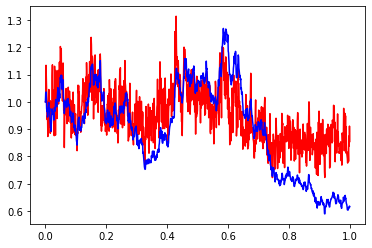

In [29]:
# plot a single trajectory of the price and vol
plt.plot(solutions.ts[0,:], solutions.ys[0, :, 1], color = "red")
plt.plot(solutions.ts[0,:], solutions.ys[0, :, 0], color = "blue")

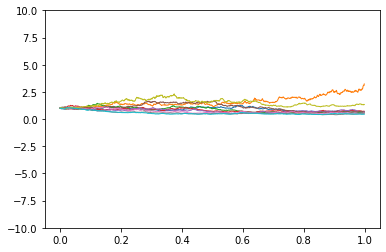

In [30]:
# Assuming M and solutions are defined
for k in range(10):
    # Plot using the next color in the default cycle
    plt.plot(solutions.ts[0, :], solutions.ys[k, :, 0],linewidth=1)

plt.ylim(-10, 10)
plt.show()

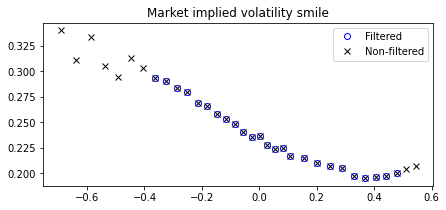

We use the filtered data for calibration only


In [36]:
r,q = 0.,0.
S0 = 179.83

data = pd.read_csv('dataOptionPrices.csv')
def logstrike(S0,K,T): return np.log(K/S0*np.exp(-(r-q)*T))
data['LogStrike'] = [logstrike(S0,K,T) for K,T in zip(data['Strike'],data['Expiration'])]

data['IV'] = [impliedVolJaeckelRational(S0, K, c, T) for K,T,c in zip(data['Strike'],data['Expiration'],data['midPrice'])]

ListMat = data["Expiration"].unique()
indexMat = -2 ## Select maturity index

df_filt = data[(data["Expiration"] == ListMat[indexMat]) & (data["IV"] >0.) & (data["IV"] <1.) & (data["LogStrike"] < 0.5) & (data["LogStrike"] > -0.4)]
df_nonfilt = data[data["Expiration"] == ListMat[indexMat]]

plt.figure(figsize=(7,3))
plt.plot(df_filt["LogStrike"].values, df_filt["IV"].values, "bo", mfc="None", label="Filtered")
plt.plot(df_nonfilt["LogStrike"].values, df_nonfilt["IV"].values, "kx", mfc="None", label="Non-filtered")
plt.title("Market implied volatility smile")
plt.legend(loc="best")
plt.show()
print("We use the filtered data for calibration only")

ivs_market = df_filt["IV"].values
strikes = df_filt["Strike"].values
T = ListMat[indexMat]

In [37]:
nbStrikes = 25
grid_points = 300
nbPaths = 30000
grid = np.linspace(0,T,grid_points)


Call_prices=[jnp.mean(jnp.maximum(S0*solutions.ys[:, -1, 0] - K,0)) for K in strikes]

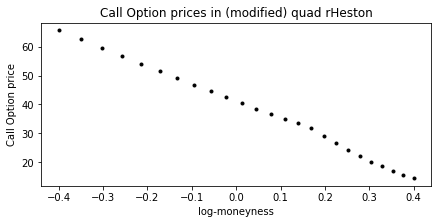

In [38]:
nbStrikes = 25
grid_points = 300
nbPaths = 30000
grid = np.linspace(0,T,grid_points)

strikes = np.linspace(S0*np.exp(-0.4), S0*np.exp(0.4), nbStrikes)
log_moneyness = np.log(strikes/S0)
plt.figure(figsize=(7,3))
plt.plot(log_moneyness,Call_prices, 'k.')
#plt.plot(log_moneyness,Call_prices_fixedH, 'b+')
plt.xlabel('log-moneyness')
plt.ylabel('Call Option price')
plt.title('Call Option prices in (modified) quad rHeston')
plt.show()